In [1]:
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import numpy as np
import matplotlib.pyplot as plt

import fci
import mbpt
import rpa as rpamod
import coupledcluster as cc
import quantumdot as qd

np.set_printoptions(precision=6, suppress=True, linewidth=120)

print("exact two-electron energy at hbar omega = 1 (Taut) :", qd.taut_energy())

exact two-electron energy at hbar omega = 1 (Taut) : 3.0


In [2]:
cc.demo_comparison()

6. Everything against everything
The pairing model, treated by every method in the book.



     g        HF      MBPT2      MBPT3        CID        RPA         CCD         FCI
  0.25   1.75000    1.73177    1.73047    1.73051    1.71635   1.7304562   1.7304598
  0.50   1.50000    1.42708    1.41667    1.41760    1.37450   1.4166377   1.4167743
  1.00   1.00000    0.70833    0.62500    0.64891    0.55459   0.6304428   0.6355485
  1.50   0.50000   -0.15625   -0.43750   -0.29113   -0.40625  -0.3841653  -0.3481905
  2.00   0.00000   -1.16667   -1.83333   -1.35209   -1.47622  -1.6095944  -1.4896522

The errors:
     g       MBPT2       MBPT3         CID         RPA         CCD
  0.25    1.31e-03    8.90e-06    4.72e-05   -1.41e-02   -3.63e-06
  0.50    1.03e-02   -1.08e-04    8.22e-04   -4.23e-02   -1.37e-04
  1.00    7.28e-02   -1.05e-02    1.34e-02   -8.10e-02   -5.11e-03
  1.50    1.92e-01   -8.93e-02    5.71e-02   -5.81e-02   -3.60e-02
  2.00    3.23e-01   -3.44e-01    1.38e-01    1.34e-02   -1.20e-01

At weak and moderate coupling coupled cluster is the best of the
five by t

In [3]:
g_grid = np.linspace(0.05, 3.0, 30)
fock = rpamod.FockSpace(4)                 # built once and reused

labels = ["HF", "MBPT2", "MBPT3", "CID", "RPA", "CCD", "FCI"]
E = {label: [] for label in labels}

for g in g_grid:
    h, v, N = cc.pairing_model(levels=4, particles=4, g=g)
    f = cc.fock_matrix(h, v, N)
    e_ref = cc.reference_energy(h, v, N)

    E["HF"].append(e_ref)
    E["CCD"].append(e_ref + cc.ccd(f, v, N)["energy"])

    partition, model = mbpt.pairing_partition(levels=4, particles=4, g=g)
    rs = mbpt.rayleigh_schrodinger(partition, order=3)
    E["MBPT2"].append(partition.reference_energy + rs[1])
    E["MBPT3"].append(partition.reference_energy + rs[1] + rs[2])
    E["CID"].append(model.energies(2)[0])

    r = rpamod.tda_rpa(fock, N, g, 0.0)
    E["RPA"].append(r["hf"] + r["ecorr"])

    E["FCI"].append(cc.fci_energy(h, v, N)[0])

E = {label: np.array(values) for label, values in E.items()}
approximations = ["MBPT2", "MBPT3", "CID", "RPA", "CCD"]
error = {label: E[label] - E["FCI"] for label in approximations}

print(f"{'g':>6s}  " + "".join(f"{label:>11s}" for label in approximations)
      + "   best")
for i in range(0, len(g_grid), 3):
    best = min(approximations, key=lambda label: abs(error[label][i]))
    print(f"{g_grid[i]:6.2f}  "
          + "".join(f"{error[label][i]:11.2e}" for label in approximations)
          + f"   {best}")

     g        MBPT2      MBPT3        CID        RPA        CCD   best
  0.05     1.04e-05   3.11e-08   6.83e-08  -6.94e-04  -9.91e-10   CCD
  0.36     3.74e-03   1.07e-05   2.00e-04  -2.53e-02  -2.26e-05   MBPT3
  0.66     2.31e-02  -8.63e-04   2.57e-03  -5.98e-02  -5.92e-04   CCD
  0.97     6.64e-02  -8.66e-03   1.17e-02  -8.01e-02  -4.27e-03   CCD
  1.27     1.32e-01  -3.85e-02   3.23e-02  -7.63e-02  -1.67e-02   CCD
  1.58     2.12e-01  -1.14e-01   6.70e-02  -4.96e-02  -4.48e-02   CCD
  1.88     2.94e-01  -2.61e-01   1.15e-01  -6.28e-03  -9.42e-02   RPA
  2.19     3.64e-01  -5.07e-01   1.76e-01   4.61e-02  -1.67e-01   RPA
  2.49     4.13e-01  -8.75e-01   2.46e-01   1.01e-01  -2.64e-01   RPA
  2.80     4.34e-01  -1.39e+00   3.24e-01   1.55e-01  -3.82e-01   RPA


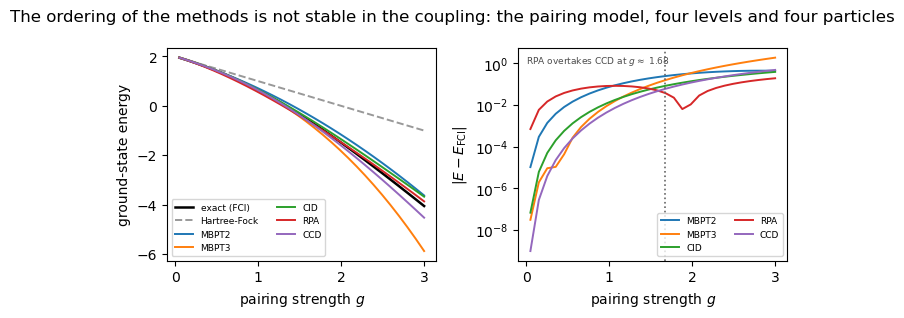

In [4]:
colour = {"MBPT2": "C0", "MBPT3": "C1", "CID": "C2",
          "RPA": "C3", "CCD": "C4"}

# where the RPA first becomes more accurate than coupled cluster
better = np.abs(error["RPA"]) < np.abs(error["CCD"])
g_cross = g_grid[np.argmax(better)] if better.any() else None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.2))

ax1.plot(g_grid, E["FCI"], "k-", lw=1.8, label="exact (FCI)")
ax1.plot(g_grid, E["HF"], color="0.6", ls="--", lw=1.4, label="Hartree-Fock")
for label in approximations:
    ax1.plot(g_grid, E[label], colour[label], lw=1.4, label=label)
ax1.set_xlabel("pairing strength $g$")
ax1.set_ylabel("ground-state energy")
ax1.legend(fontsize=6.5, loc="lower left", ncol=2)

for label in approximations:
    ax2.semilogy(g_grid, np.maximum(np.abs(error[label]), 1e-12),
                 colour[label], lw=1.4, label=label)
if g_cross is not None:
    ax2.axvline(g_cross, color="0.4", ls=":", lw=1.2)
    ax2.text(0.03, 0.97, f"RPA overtakes CCD at $g \\approx$ {g_cross:.2f}",
             transform=ax2.transAxes, va="top", fontsize=6.5, color="0.3")
ax2.set_xlabel("pairing strength $g$")
ax2.set_ylabel(r"$|E - E_{\mathrm{FCI}}|$")
ax2.legend(fontsize=6.5, loc="lower right", ncol=2)

fig.suptitle("The ordering of the methods is not stable in the coupling: "
             "the pairing model, four levels and four particles")
fig.tight_layout()
plt.show()

SlaterBasis(14, 7).dim = 3432    fci.comb(14, 7) = 3432

    n     dim FCI (N = n/2)    CCSD ~ n^6   MBPT2 ~ n^5    HF ~ n^4
   20             1.848e+05     6.400e+07     3.200e+06   1.600e+05
   40             1.378e+11     4.096e+09     1.024e+08   2.560e+06
   60             1.183e+17     4.666e+10     7.776e+08   1.296e+07
   80             1.075e+23     2.621e+11     3.277e+09   4.096e+07
  100             1.009e+29     1.000e+12     1.000e+10   1.000e+08


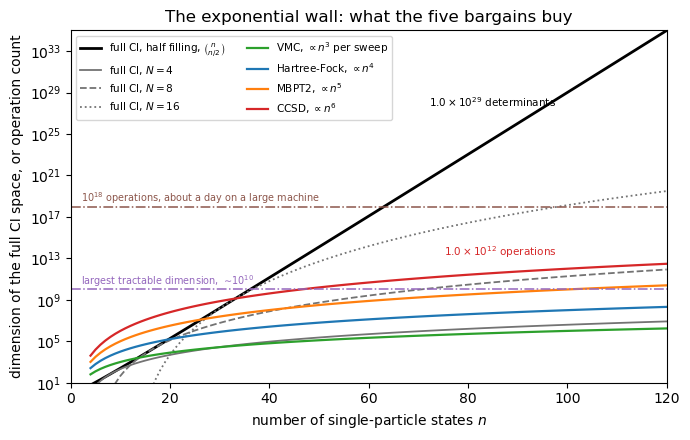

In [5]:
check = fci.SlaterBasis(14, 7)
print("SlaterBasis(14, 7).dim =", check.dim,
      "   fci.comb(14, 7) =", fci.comb(14, 7))

n = np.arange(4, 121)
half = n[n % 2 == 0]
dim_half = np.array([fci.comb(int(k), int(k) // 2) for k in half])

print(f"\n{'n':>5s}{'dim FCI (N = n/2)':>22s}{'CCSD ~ n^6':>14s}"
      f"{'MBPT2 ~ n^5':>14s}{'HF ~ n^4':>12s}")
for k in (20, 40, 60, 80, 100):
    print(f"{k:5d}{fci.comb(k, k // 2):22.3e}{float(k)**6:14.3e}"
          f"{float(k)**5:14.3e}{float(k)**4:12.3e}")

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(half, dim_half, "k-", lw=2.0,
            label=r"full CI, half filling, $\binom{n}{n/2}$")
for N, style in ((4, "-"), (8, "--"), (16, ":")):
    ns = n[n >= N]
    ax.semilogy(ns, [fci.comb(int(k), N) for k in ns], color="0.45",
                ls=style, lw=1.3, label=rf"full CI, $N = {N}$")

for power, label, c in ((3, r"VMC, $\propto n^{3}$ per sweep", "C2"),
                        (4, r"Hartree-Fock, $\propto n^{4}$", "C0"),
                        (5, r"MBPT2, $\propto n^{5}$", "C1"),
                        (6, r"CCSD, $\propto n^{6}$", "C3")):
    ax.semilogy(n, n.astype(float) ** power, c, lw=1.6, label=label)

ax.axhline(1e10, color="C4", ls="-.", lw=1.1)
ax.text(2, 2.5e10, r"largest tractable dimension, $\sim\!10^{10}$",
        fontsize=7, color="C4", ha="left")
ax.axhline(1e18, color="C5", ls="-.", lw=1.1)
ax.text(2, 2.5e18, r"$10^{18}$ operations, about a day on a large machine",
        fontsize=7, color="C5", ha="left")

ax.annotate(r"$1.0\times10^{29}$ determinants", (100, fci.comb(100, 50)),
            textcoords="offset points", xytext=(-8, -2), ha="right",
            va="top", fontsize=7.5)
ax.annotate(r"$1.0\times10^{12}$ operations", (100, 100.0 ** 6),
            textcoords="offset points", xytext=(-8, 6), ha="right",
            va="bottom", fontsize=7.5, color="C3")

ax.set_xlim(0, 120)
ax.set_ylim(1e1, 1e35)
ax.set_xlabel("number of single-particle states $n$")
ax.set_ylabel("dimension of the full CI space, or operation count")
ax.set_title("The exponential wall: what the five bargains buy")
ax.legend(fontsize=7.5, loc="upper left", ncol=2)
fig.tight_layout()
plt.show()

In [6]:
shells = [2, 3, 4, 5, 6]
rows = []
for R in shells:
    out = qd.solve(2, R, hw=1.0, methods=("hf", "mp2", "ccsd"))
    e_fci, dimension = qd.two_electron_fci(out["h_hf"], out["v_hf"])
    rows.append(dict(shells=R, n=out["n_orbitals"], dim=dimension,
                     HF=out["E_HF"],
                     MP2=out["E_HF"] + out["E_MP2"],
                     CCSD=out["E_HF"] + out["E_CCSD"],
                     FCI=e_fci))

exact = qd.taut_energy()
methods = ["HF", "MP2", "CCSD", "FCI"]

print(f"{'shells':>7s}{'orbitals':>10s}{'FCI dim':>9s}"
      + "".join(f"{m:>12s}" for m in methods))
for row in rows:
    print(f"{row['shells']:7d}{row['n']:10d}{row['dim']:9d}"
          + "".join(f"{row[m]:12.6f}" for m in methods))

print(f"\nerrors against the exact {exact:.1f}:")
for row in rows:
    print(f"{row['shells']:7d}{row['n']:10d}{'':9s}"
          + "".join(f"{row[m] - exact:12.2e}" for m in methods))

 shells  orbitals  FCI dim          HF         MP2        CCSD         FCI
      2        12       66    3.162691    3.057976    3.038605    3.038605
      3        20      190    3.162691    3.044404    3.025231    3.025231
      4        30      435    3.161921    3.033418    3.017606    3.017606
      5        42      861    3.161921    3.027038    3.013626    3.013626
      6        56     1540    3.161909    3.022213    3.011020    3.011020

errors against the exact 3.0:
      2        12             1.63e-01    5.80e-02    3.86e-02    3.86e-02
      3        20             1.63e-01    4.44e-02    2.52e-02    2.52e-02
      4        30             1.62e-01    3.34e-02    1.76e-02    1.76e-02
      5        42             1.62e-01    2.70e-02    1.36e-02    1.36e-02
      6        56             1.62e-01    2.22e-02    1.10e-02    1.10e-02


CCSD/FCI basis error falls as n^-0.80
a chemical-accuracy 1e-3 would need about 1095 spin-orbitals


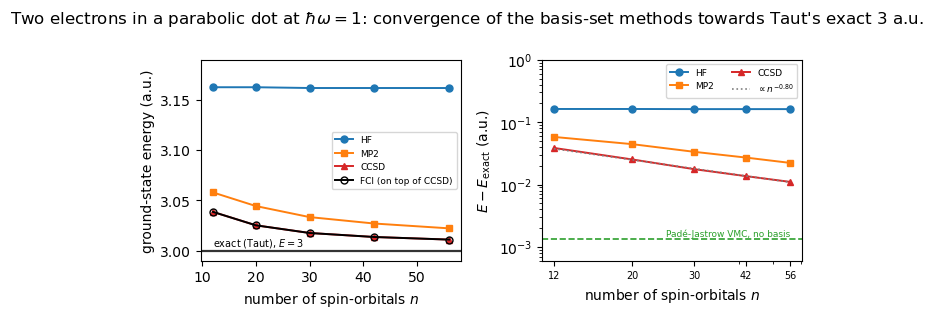

In [7]:
n_orb = np.array([row["n"] for row in rows], dtype=float)
energies = {m: np.array([row[m] for row in rows]) for m in methods}
errors = {m: energies[m] - exact for m in methods}
vmc = 3.001323          # Pade-Jastrow VMC, chapter 13, table 21.1

# rate of convergence of the basis-set error, from the four largest bases
slope, intercept = np.polyfit(np.log(n_orb[1:]), np.log(errors["CCSD"][1:]), 1)
n_needed = np.exp((np.log(1e-3) - intercept) / slope)
print(f"CCSD/FCI basis error falls as n^{slope:.2f}")
print(f"a chemical-accuracy 1e-3 would need about {n_needed:.0f} spin-orbitals")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.2))

style = {"HF": ("C0", "o"), "MP2": ("C1", "s"),
         "CCSD": ("C3", "^"), "FCI": ("k", "o")}
for m in methods:
    c, marker = style[m]
    fill = "none" if m == "FCI" else c
    ax1.plot(n_orb, energies[m], marker=marker, color=c, lw=1.4, ms=5,
             mfc=fill, label=m + (" (on top of CCSD)" if m == "FCI" else ""))
ax1.axhline(exact, color="0.2", lw=1.6)
ax1.text(12, exact + 0.005, "exact (Taut), $E = 3$", fontsize=7)
ax1.set_xlabel("number of spin-orbitals $n$")
ax1.set_ylabel("ground-state energy (a.u.)")
ax1.set_ylim(2.99, 3.19)
ax1.legend(fontsize=6.5, loc="center right")

for m in methods[:3]:
    c, marker = style[m]
    ax2.loglog(n_orb, errors[m], marker=marker, color=c, lw=1.4, ms=5,
               label=m)
ax2.loglog(n_orb, np.exp(intercept) * n_orb ** slope, "0.5", ls=":", lw=1.2,
           label=rf"$\propto n^{{{slope:.2f}}}$")
ax2.axhline(vmc - exact, color="C2", ls="--", lw=1.2)
ax2.text(56, 1.5e-3, "Padé-Jastrow VMC, no basis", fontsize=6.5,
         color="C2", ha="right")
ax2.set_xlabel("number of spin-orbitals $n$")
ax2.set_ylabel(r"$E - E_{\mathrm{exact}}$ (a.u.)")
ax2.set_xticks(n_orb)
ax2.set_xticklabels([f"{int(k)}" for k in n_orb], fontsize=7)
ax2.xaxis.set_minor_formatter(plt.NullFormatter())
ax2.set_ylim(6e-4, 1.0)
ax2.legend(fontsize=6.5, loc="upper right", ncol=2)

fig.suptitle("Two electrons in a parabolic dot at $\\hbar\\omega=1$: "
             "convergence of the basis-set methods towards Taut's exact 3 a.u.")
fig.tight_layout()
plt.show()